### How to use this notebook

This notebook implements data analysis and machine learning, including data exploration, data transformation, and result interpretation using an LLM (Ollama).

#### This notebook uses Ollama to generate summaries of the machine learning results

#### How to run LLM component:

Install Ollama:
https://apxml.com/courses/getting-started-local-llms/chapter-4-running-first-local-llm/setting-up-ollama

Pull the llama3 model from terminal: ollama pull llama3

Start the Ollama server from terminal: ollama serve

### Use of AI

In this project, ChatGPT was used in the following ways:

- To gain a better understanding of exactly what the core components and the additional requirements for the project necessitates
- Explain concepts
- Assisted in deciding the appropriate hyperparameters for the ML models
- Assisted in generating a prompt for the LLM summary of results
- Disabling warnings from the ML models
- Creating the export .csv for results

### Introduction

This project analyzes specific parts of the Drug Consumption (Quantified) dataset. The original dataset includes quantitative data on the drug consumption habits of individuals, as well as 12 different features ranging from personality measurements to level of education, age, gender, country and ethnicity.

The goal of the project is to visualize the drug consumption patterns of respondents, and build predictive machine learning models that estimate nicotine consumption levels based on the features available in the dataset.

Therefore, the goal is to answer the following question:
#### How well can nicotine consumption habits be predicted using personality measurements and demographic data?

Link to original dataset: https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified

In [1]:
#Installing required repo for dataset importing
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
drug_consumption_quantified = fetch_ucirepo(id=373) 
  
# data (as pandas dataframes) 
X = drug_consumption_quantified.data.features 
y = drug_consumption_quantified.data.targets 
  
# metadata 
#print(drug_consumption_quantified.metadata) 
  
# variable information 
#print(drug_consumption_quantified.variables) 

display(X)
display(y)

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575
...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470


,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,CL5,CL2,CL0,CL2,CL6,CL0,CL5,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,CL5,CL2,CL2,CL0,CL6,CL4,CL6,CL3,CL0,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,CL6,CL0,CL0,CL0,CL6,CL3,CL4,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,CL4,CL0,CL0,CL3,CL5,CL2,CL4,CL2,CL0,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,CL4,CL1,CL1,CL0,CL6,CL3,CL6,CL0,CL0,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,CL5,CL0,CL0,CL0,CL4,CL5,CL4,CL0,CL0,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,CL5,CL0,CL0,CL0,CL5,CL3,CL4,CL0,CL0,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,CL4,CL6,CL5,CL5,CL6,CL6,CL6,CL4,CL0,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,CL5,CL0,CL0,CL0,CL6,CL6,CL5,CL0,CL0,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [3]:
#Combining features and targets into one df containing raw data
raw_df = pd.concat([X, y], axis=1)
display(raw_df)

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [4]:
#Exporting the raw data
raw_df.to_csv("raw_data.csv", index=False)

In [5]:
#Uncomment next line for importing of raw data
#raw_df = pd.read_csv("raw_data.csv")

### Data cleaning and transformation (preprocessing)

In [6]:
#Checking the Dtype of each column
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

In [7]:
#Making sure there are no missing values
raw_df.isna().sum()

age          0
gender       0
education    0
country      0
ethnicity    0
nscore       0
escore       0
oscore       0
ascore       0
cscore       0
impuslive    0
ss           0
alcohol      0
amphet       0
amyl         0
benzos       0
caff         0
cannabis     0
choc         0
coke         0
crack        0
ecstasy      0
heroin       0
ketamine     0
legalh       0
lsd          0
meth         0
mushrooms    0
nicotine     0
semer        0
vsa          0
dtype: int64

In [8]:
#Renaming some of the target columns to give them more descriptive names
renamed_df = raw_df.rename(columns={
    "amphet": "amphetamine",
    "amyl": "amyl_nitrite",
    "benzos": "benzodiazepines",
    "caff": "caffeine",
    "choc": "chocolate",
    "coke": "cocaine",
    "crack": "crack_cocaine",
    "legalh": "legal_h",
    "meth": "methamphetamine",
    "vsa": "valproic_acid"
})

In [9]:
#Creating a copy of the raw df incase of need to revert back to this point
copy_renamed_df = renamed_df.copy()

In [10]:
#Mapping the target values from objects to int64 so that the model is able to read them
target_mapping = {
    "CL0": 0,
    "CL1": 1,
    "CL2": 2,
    "CL3": 3,
    "CL4": 4,
    "CL5": 5,
    "CL6": 6,
}

In [11]:
#Iterating through all columns in raw_df and saving cols of dtype object to a variable
#https://stackoverflow.com/questions/52878191/using-pandas-dtype-as-a-condition

target_columns = [
    i for i in renamed_df.select_dtypes(['object'])
]
print(target_columns)

['alcohol', 'amphetamine', 'amyl_nitrite', 'benzodiazepines', 'caffeine', 'cannabis', 'chocolate', 'cocaine', 'crack_cocaine', 'ecstasy', 'heroin', 'ketamine', 'legal_h', 'lsd', 'methamphetamine', 'mushrooms', 'nicotine', 'semer', 'valproic_acid']


In [12]:
#Resolving FutureWarning related to .replace
pd.set_option('future.no_silent_downcasting', True)

#Replacing the dtype object target values with int values
mapped_targets = renamed_df[target_columns].replace(target_mapping).astype("int64")

#Creating new dataframe for transformed target values
df = copy_renamed_df
df[target_columns] = mapped_targets

display(df)

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,...,ecstasy,heroin,ketamine,legal_h,lsd,methamphetamine,mushrooms,nicotine,semer,valproic_acid
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,0,0,0,0,0,0,0,2,0,0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,4,0,2,0,2,3,0,4,0,0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,0,0,0,0,0,0,1,0,0,0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,0,0,2,0,0,0,0,2,0,0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,1,0,0,1,0,0,2,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,...,0,0,0,3,3,0,0,0,0,5
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,...,2,0,0,3,5,4,4,5,0,0
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,...,4,0,2,0,2,0,2,6,0,0
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,...,3,0,0,3,3,0,3,4,0,0


### Visual and quantitative analysis

In [13]:
#Creating labels for visuals
label_map = {
    0: "Never",
    1: ">10 yrs Ago",
    2: "<10 yrs Ago",
    3: "Last Year",
    4: "Last Month",
    5: "Last Week",
    6: "Last Day"
}

In [14]:
label_order = [
    "Never",
    ">10 yrs Ago",
    "<10 yrs Ago",
    "Last Year",
    "Last Month",
    "Last Week",
    "Last Day"
]

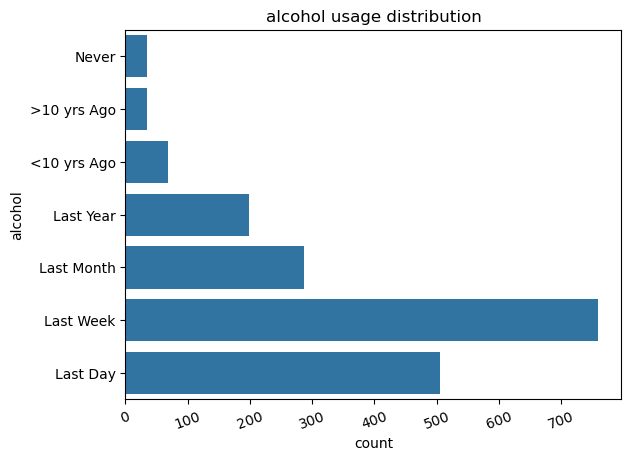

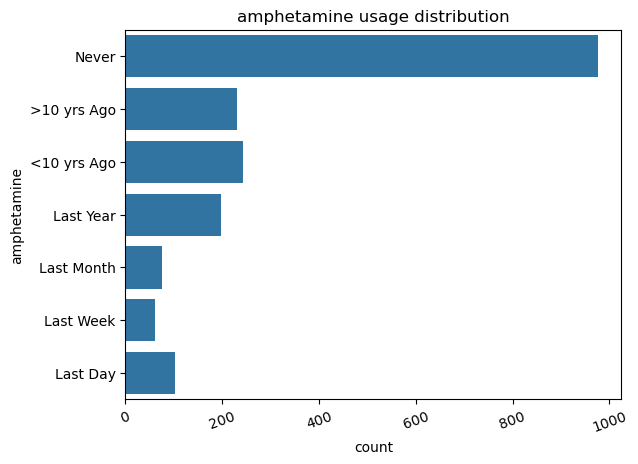

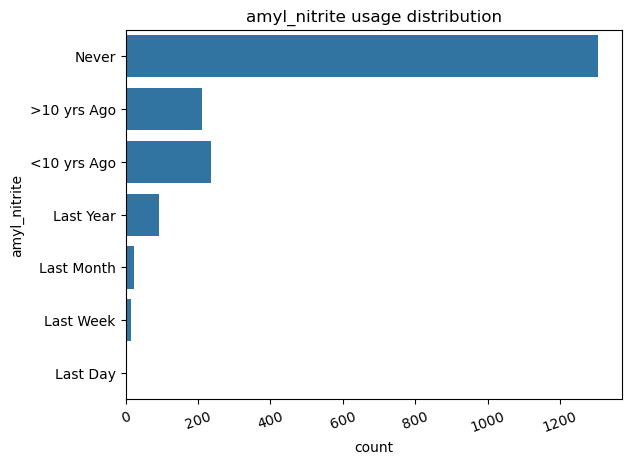

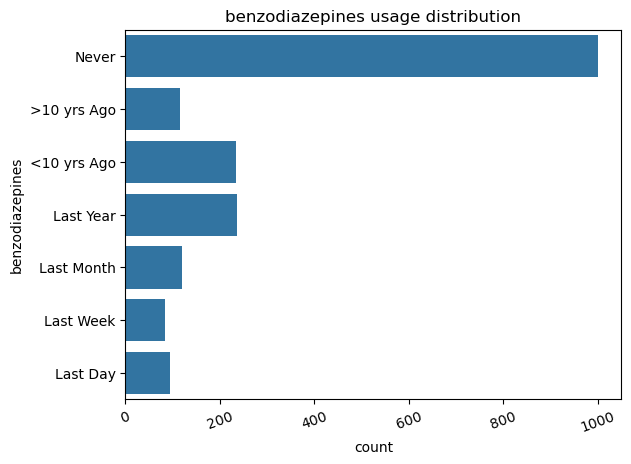

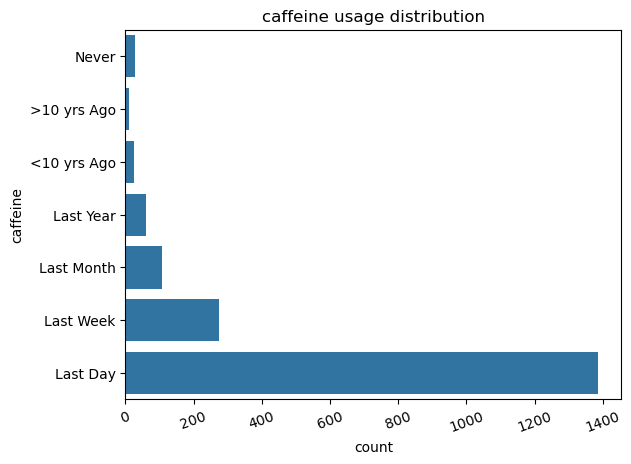

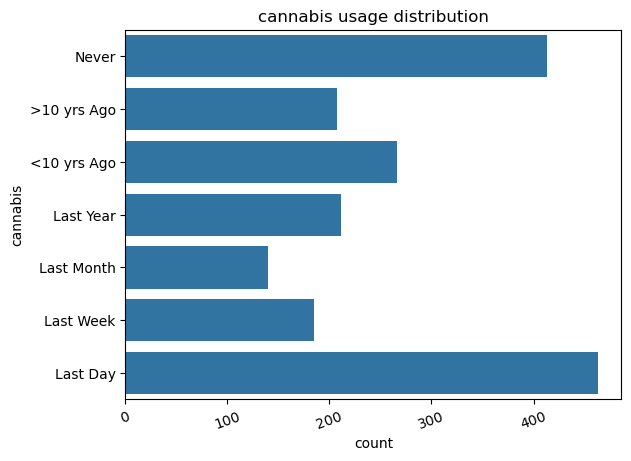

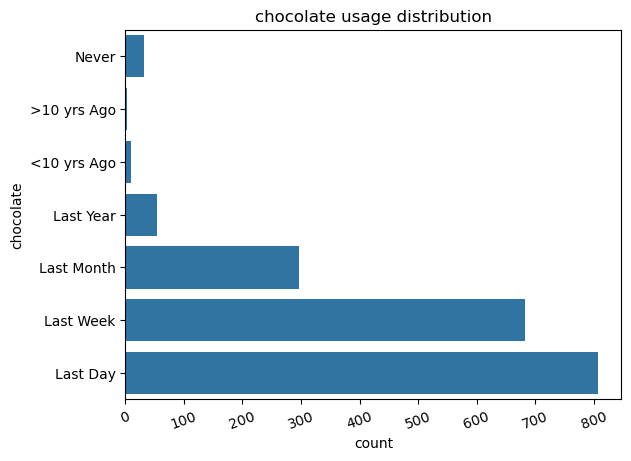

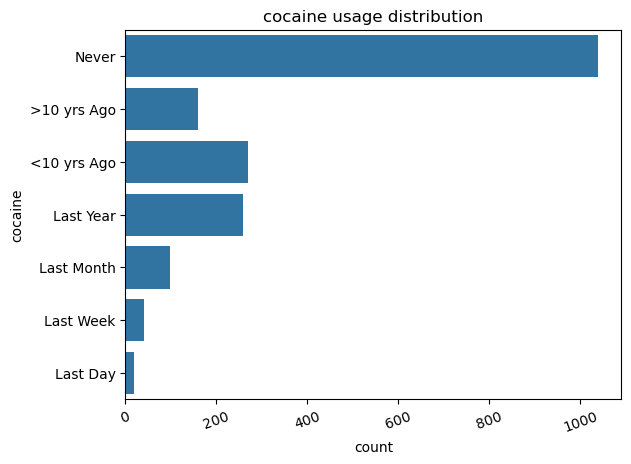

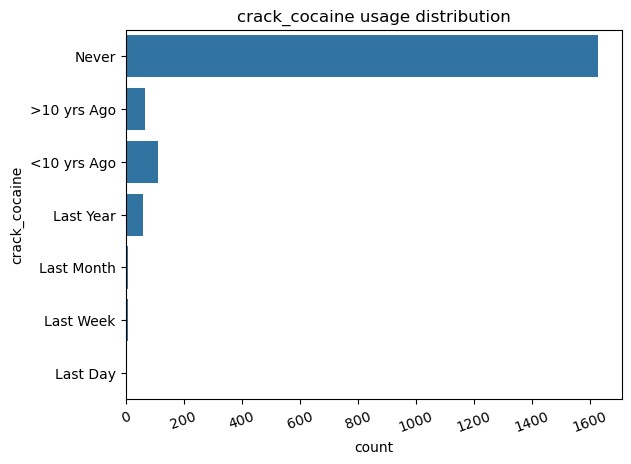

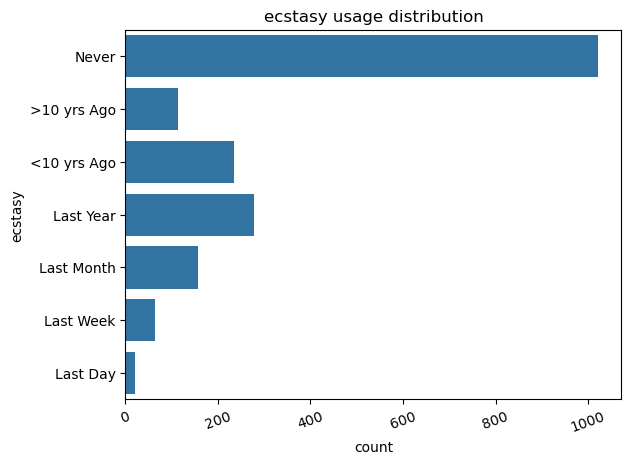

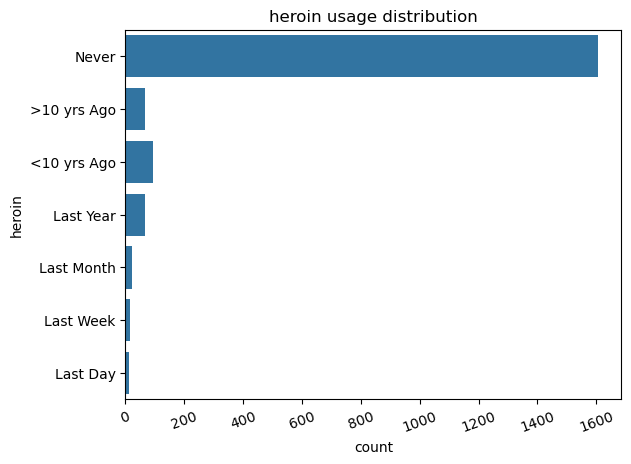

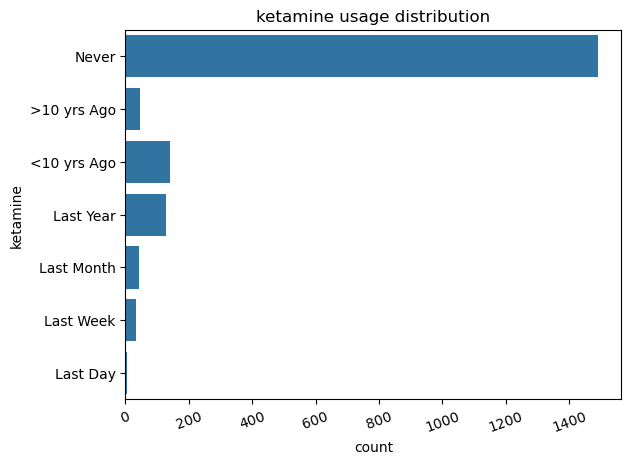

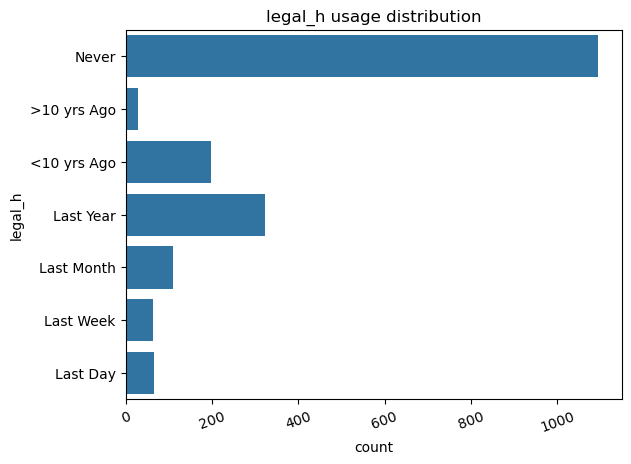

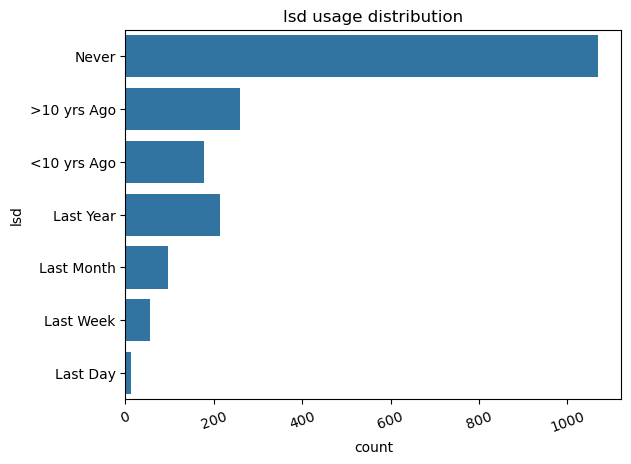

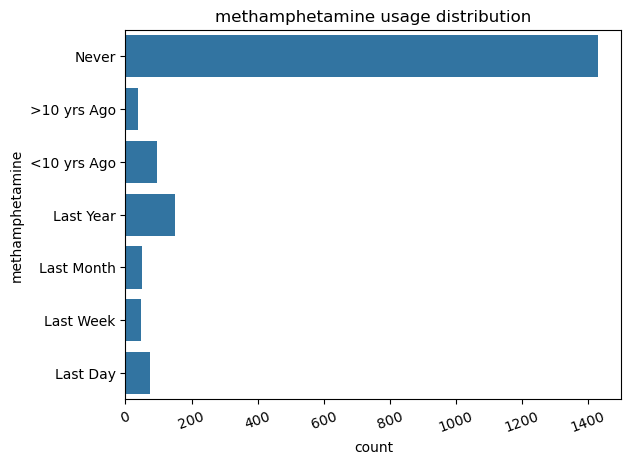

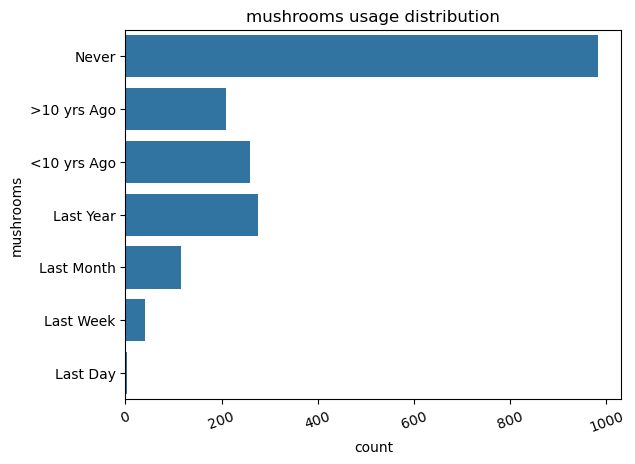

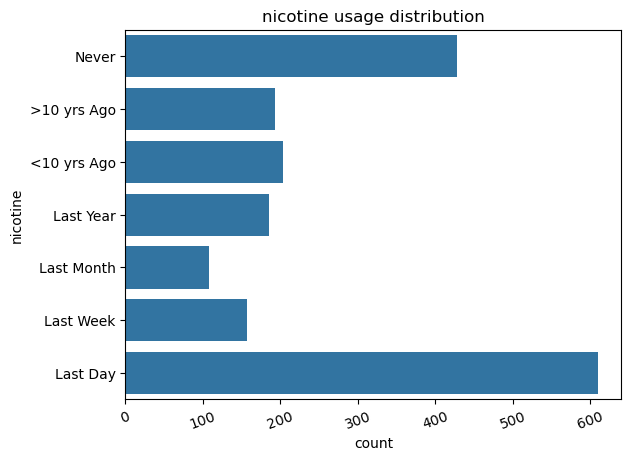

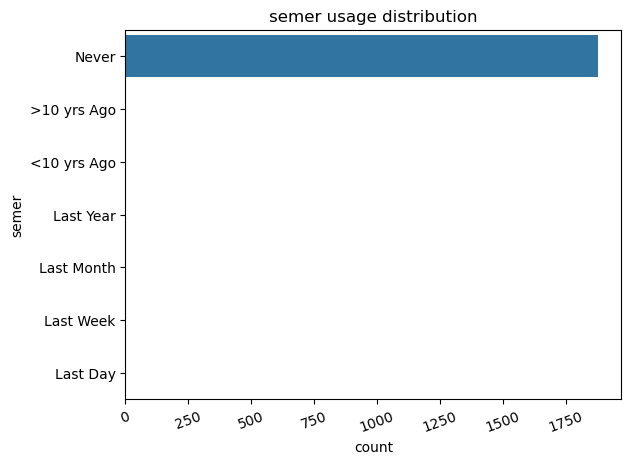

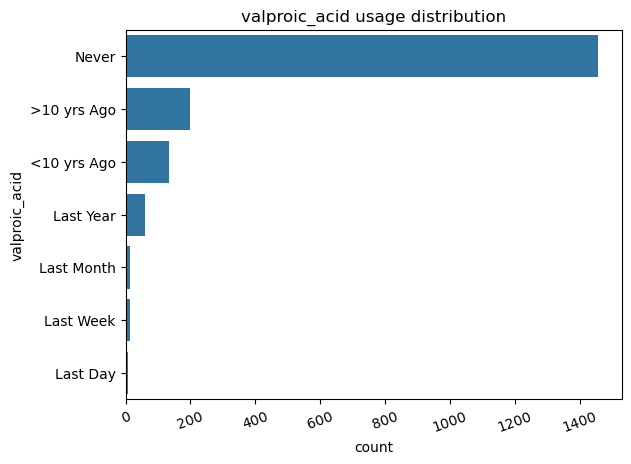

In [15]:
import seaborn as sb
import matplotlib.pyplot as plt

#Generating a barchart for the usage distribution of each drug
for i in target_columns:
    mapped = df[i].map(label_map)
    
    sb.countplot(mapped, order=label_order)
    plt.title(f"{i} usage distribution")
    plt.xticks(rotation=20)
    plt.show()

#### Machine learning on the target column nicotine, using Logistic Regression and Random Forest

In [16]:
#Separating features from the target, X was already separated in the beginning of the notebook:
#X = drug_consumption_quantified.data.features 

In [17]:
y = df["nicotine"]

In [18]:
from sklearn.model_selection import train_test_split

#Train-validation-test split, from E6
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass balance (train):")
print(y_train.value_counts())

Train set size: 1131
Validation set size: 377
Test set size: 377

Class balance (train):
nicotine
6    359
0    244
1    127
3    124
2    121
5     93
4     63
Name: count, dtype: int64


In [19]:
#Training a Logistic Regression model to make predictions
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_val)

In [20]:
#Training a Random Forest model to make predictions
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

#### Evaluating the models

In [21]:
from sklearn.metrics import classification_report

#Storing results in a variable in order to later pass them into the LLM prompt
report_lr = classification_report(y_val, y_pred_lr, output_dict=True, zero_division=0)
report_rf = classification_report(y_val, y_pred_rf, output_dict=True, zero_division=0)

#Evaluating Logistic Regression model
print(classification_report(y_val, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       0.47      0.30      0.37        93
           1       0.24      0.53      0.33        32
           2       0.19      0.15      0.17        39
           3       0.08      0.18      0.11        28
           4       0.11      0.19      0.14        26
           5       0.04      0.07      0.05        30
           6       0.59      0.26      0.36       129

    accuracy                           0.25       377
   macro avg       0.25      0.24      0.22       377
weighted avg       0.37      0.25      0.28       377



In [22]:
print(classification_report(y_val, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       0.48      0.49      0.49        93
           1       0.31      0.16      0.21        32
           2       0.25      0.03      0.05        39
           3       0.42      0.18      0.25        28
           4       0.00      0.00      0.00        26
           5       0.50      0.07      0.12        30
           6       0.44      0.84      0.58       129

    accuracy                           0.44       377
   macro avg       0.34      0.25      0.24       377
weighted avg       0.39      0.44      0.37       377



### Connecting to an LLM and using it to summarize the results from the logistic regression and random forest model

In [23]:
#Used ChatGPT to generate a good prompt for analyzing the results
prompt = f"""
You are a data science analyst.

Compare two models trained on a multiclass classification task (CL0–CL6).

Results:

Logistic Regression:
{report_lr}

Random Forest:
{report_rf}

Explain:
1. Which model performs better and why
2. Impact of class imbalance
3. Key weaknesses of each model

Write a short report-style answer.
"""

In [24]:

from ollama import chat
from dotenv import load_dotenv
import os
import requests

load_dotenv()

BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
MODEL = os.getenv("OLLAMA_MODEL", "llama3")

response = requests.post(
    f"{BASE_URL}/api/generate",
    json={
        "model": MODEL,
        "prompt": prompt,
        "stream": False
})

print(response.json()["response"])

Report: Comparative Analysis of Logistic Regression and Random Forest Models on Multiclass Classification Task (CL0–CL6)

**Model Performance**

The Random Forest model outperforms the Logistic Regression model in terms of overall accuracy (0.44297082228116713 vs 0.2546419098143236). The Random Forest model also shows improved performance for classes 1, 3, and 6, while the Logistic Regression model struggles with these classes.

**Impact of Class Imbalance**

The data appears to be imbalanced, with class 6 having a significantly higher frequency than other classes. This imbalance can affect the performance of both models. The Random Forest model is more robust to class imbalance, as it relies on ensemble learning and can handle diverse training samples. In contrast, the Logistic Regression model is more sensitive to class imbalance, which may lead to biased predictions.

**Key Weaknesses**

1. **Logistic Regression**:
	* Overfitting: The model's performance suffers due to its inability

### Exporting predictions as a .csv

In [25]:
results_df = pd.DataFrame({
    "y_true": y_val,
    "y_pred_lr": y_pred_lr,
    "y_pred_rf": y_pred_rf
})

results_df.to_csv("model_predictions.csv", index=False)

### Conclusion

The results of the data visualization showed that drug usage habits are imbalanced across all drugs. Usage habits usually skewed to the lower end of the range (CL0-CL2) regarding the more harsh or nieche drugs, while more tame substances showed much more frequent usage habits (CL3-CL6). Nicotine and cannabis created a divide in the usage habits of the respondents, as both substances tilted heavliy towards both extremes (CL0 & CL6).

When attempting to predict usage habits based on personality measurements and demographic data, two machine learning models where trained and applied: Logistic Regression and Random Forest. The Random Forest model outperformed the Logistic Regression model, as it is more robust and handles class imbalances better. However, both models struggled with distinguishing intermediate usage habits, especially the Logistic Regression model, which struggled especially with CL2-CL5.

Overall, the results suggest that nicotine usage habits can be partially predicted from the available features in the dataset. The large range of 7 different classification options (CL0-CL6) most likely influenced the models prediction success rate. 